In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# This magic command makes plots appear directly in the notebook
%matplotlib inline
# This sets a nice default style for our plots
sns.set_style('whitegrid')

### **Step 1: Load Your Data and Get the "Big Picture"**
We will load the clean feature data you created. The very first thing a quant does is run `.info()` and `.describe()`.

- `info()` is a quick check for data types and missing values.
- `describe()` gives you the statistical summary (mean, median, min, max) of every feature. This is your first look at the data's scale and central tendencies.

In [2]:
df_features = pd.read_parquet('../data/processed/hyp_a_features_advanced.parquet')

print("--- Data Info ---")
df_features.info()

print("\n--- Statistical Summary ---")
df_features.describe()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1994 entries, 2018-01-04 to 2025-09-24
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   day_of_week          1994 non-null   int64  
 1   asia_return          1994 non-null   float64
 2   asia_range           1994 non-null   float64
 3   london_direction     1994 non-null   int64  
 4   london_return        1994 non-null   float64
 5   RSI_14               1994 non-null   float64
 6   MOM_10               1994 non-null   float64
 7   STOCHk_14_3_3        1994 non-null   float64
 8   STOCHd_14_3_3        1994 non-null   float64
 9   STOCHh_14_3_3        1994 non-null   float64
 10  CCI_14_0.015         1994 non-null   float64
 11  ROC_10               1994 non-null   float64
 12  CMO_14               1994 non-null   float64
 13  STOCHRSIk_14_14_3_3  1994 non-null   float64
 14  STOCHRSId_14_14_3_3  1994 non-null   float64
 15  WI

,day_of_week,asia_return,asia_range,london_direction,london_return,RSI_14,MOM_10,STOCHk_14_3_3,STOCHd_14_3_3,STOCHh_14_3_3,...,WMA_10,DEMA_10,BOP,ATRr_14,PSAR,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,TRIX_30_9,TRIXs_30_9
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,...,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000
mean,1.993982,0.000264,11.352136,0.516550,0.000058,51.218199,0.815742,52.975179,53.296407,-0.321228,...,1902.145018,1902.340854,-0.008980,4.518102,1901.535325,0.422805,0.030341,0.392464,0.002292,0.002271
std,1.411004,0.003697,9.846913,0.499851,0.005917,11.522440,9.413545,26.412263,25.909256,7.056796,...,545.559218,545.792545,0.522066,2.677148,544.964228,4.471190,1.042341,4.446286,0.021228,0.020979
min,0.000000,-0.022790,1.410000,0.000000,-0.050228,19.501718,-78.640000,0.592030,1.578949,-22.632103,...,1172.281818,1170.807894,-0.992727,1.098705,1160.327200,-30.826507,-6.901261,-27.817027,-0.129286,-0.130757
25%,1.000000,-0.001611,5.645000,0.000000,-0.002718,43.099474,-3.060000,30.409695,30.793541,-4.590347,...,1511.776773,1512.302127,-0.468287,2.850151,1511.869445,-1.701027,-0.427966,-1.733139,-0.009555,-0.009420
50%,2.000000,0.000219,8.550000,1.000000,0.000198,51.132427,0.350000,53.843414,55.086194,-0.172968,...,1817.454818,1817.998808,-0.019028,3.964109,1817.914310,0.247294,0.015684,0.286640,0.001801,0.002058
75%,3.000000,0.002103,13.177500,1.000000,0.003223,59.164676,4.520000,76.121931,75.808407,3.612925,...,1995.164773,1995.635264,0.441949,5.416577,1998.338452,2.407392,0.493764,2.401043,0.014039,0.013873
max,4.000000,0.019525,84.940000,1.000000,0.027751,87.245245,65.210000,98.965691,97.912173,25.196982,...,3763.169455,3763.522402,1.000000,27.238223,3778.421083,31.394779,8.108085,29.119724,0.134120,0.125618


### **Step 2: Understanding Your Features (Univariate Analysis)**

Now we look at each feature one by one. The best tool for this is a histogram or KDE plot.

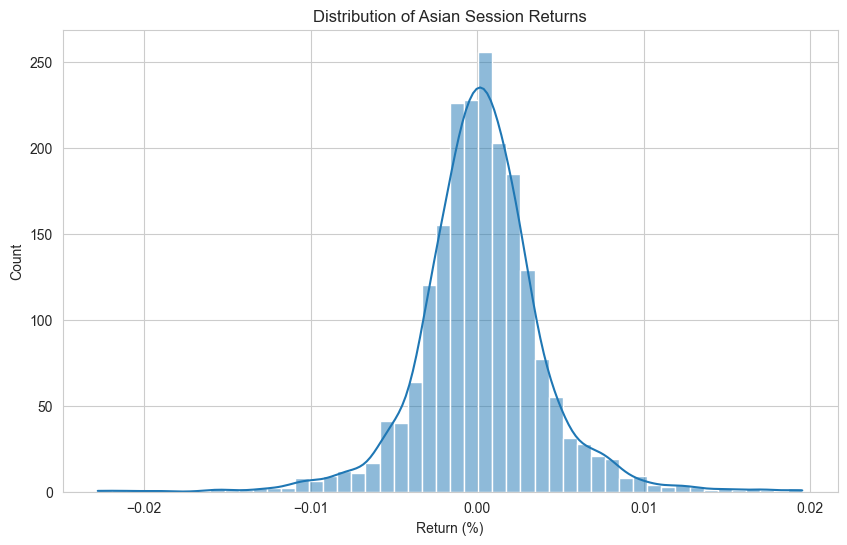

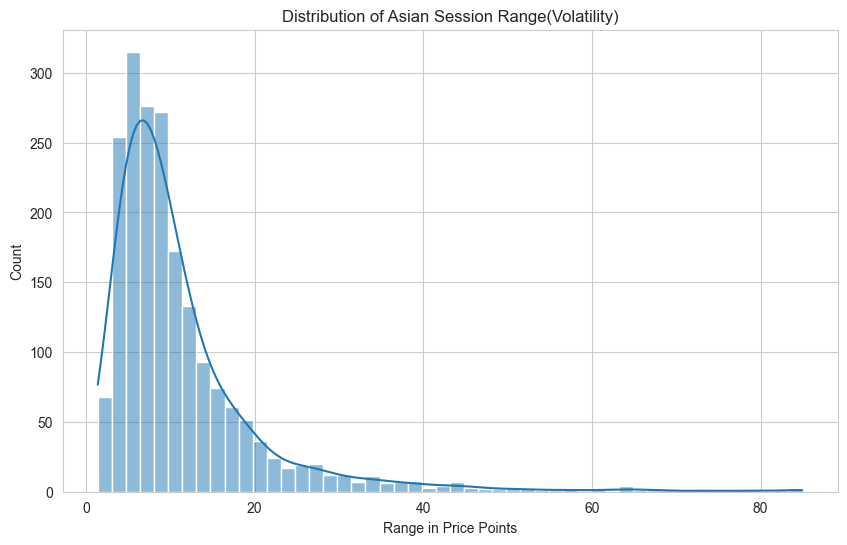

In [3]:
# Let's look at the distribution of the Asian session return
plt.figure(figsize=(10, 6))
sns.histplot(df_features['asia_return'], kde=True, bins=50)
plt.title('Distribution of Asian Session Returns')
plt.xlabel('Return (%)')
plt.show()

# distribution of asian range
plt.figure(figsize=(10, 6))
sns.histplot(data=df_features['asia_range'], kde=True, bins=50)
plt.title('Distribution of Asian Session Range(Volatility)')
plt.xlabel('Range in Price Points')
plt.show()

### **Step 3: Finding Relationships (Bivariate Analysis)**

This is where we hunt for clues that will help our model.

**Tool 1: The Correlation Matrix Heatmap**

This is the fastest way to see which variables move together.

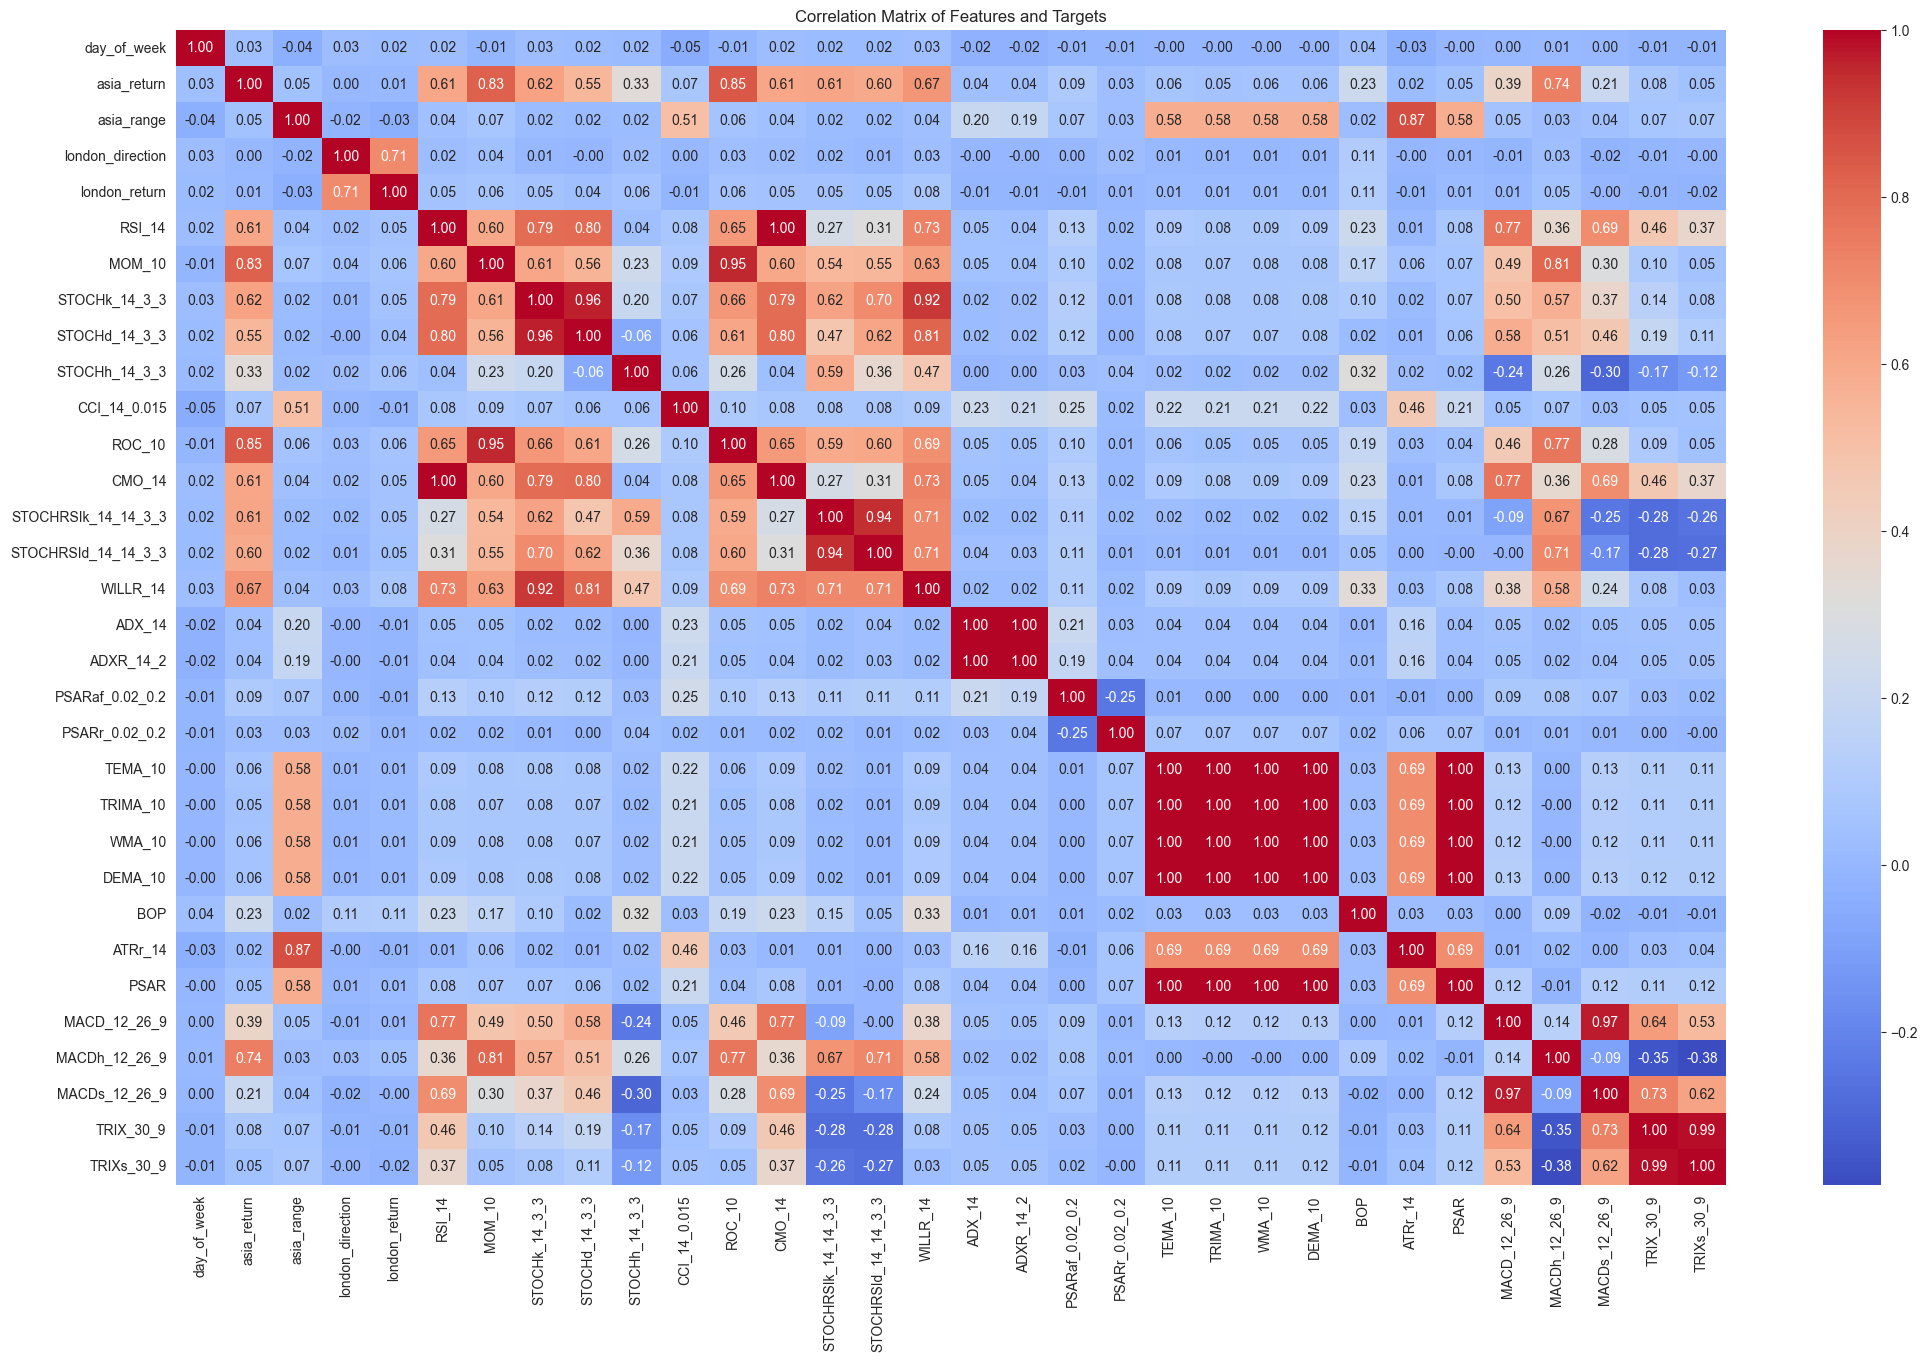

In [10]:
plt.figure(figsize=(25, 15))
# .corr() calulates the correlation between all numberic columns
sns.heatmap(df_features[
    ['day_of_week', 'asia_return', 'asia_range', 'london_direction',
       'london_return', 'RSI_14', 'MOM_10', 'STOCHk_14_3_3', 'STOCHd_14_3_3',
       'STOCHh_14_3_3', 'CCI_14_0.015', 'ROC_10', 'CMO_14',
       'STOCHRSIk_14_14_3_3', 'STOCHRSId_14_14_3_3', 'WILLR_14', 'ADX_14',
       'ADXR_14_2', 'PSARaf_0.02_0.2', 'PSARr_0.02_0.2', 'TEMA_10', 'TRIMA_10',
       'WMA_10', 'DEMA_10', 'BOP', 'ATRr_14', 'PSAR', 'MACD_12_26_9',
       'MACDh_12_26_9', 'MACDs_12_26_9', 'TRIX_30_9', 'TRIXs_30_9']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features and Targets')
plt.show()

**Tool 2: The "Money Plot" (Box Plot for Classification)**

This directly visualizes your hypothesis.

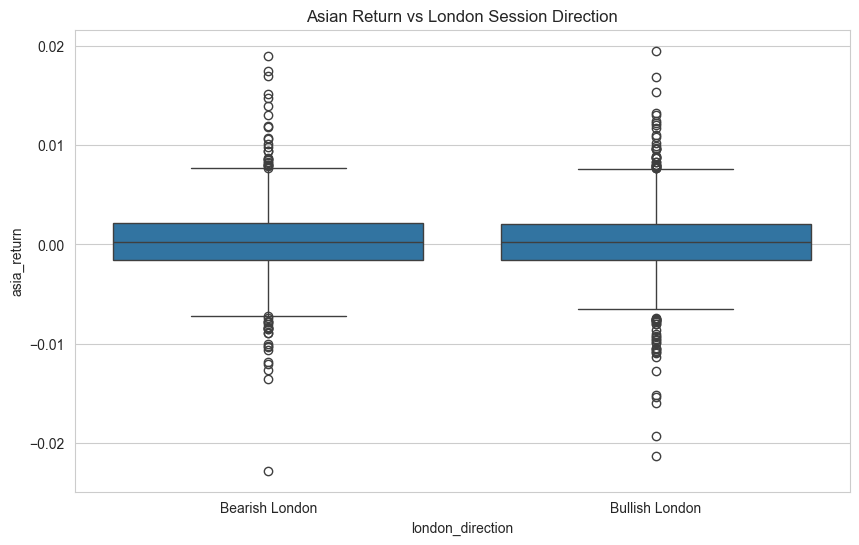

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(x='london_direction', y='asia_return', data=df_features)
plt.title('Asian Return vs London Session Direction')
plt.xticks([0,1], ['Bearish London', 'Bullish London']) # make labels readable
plt.show()

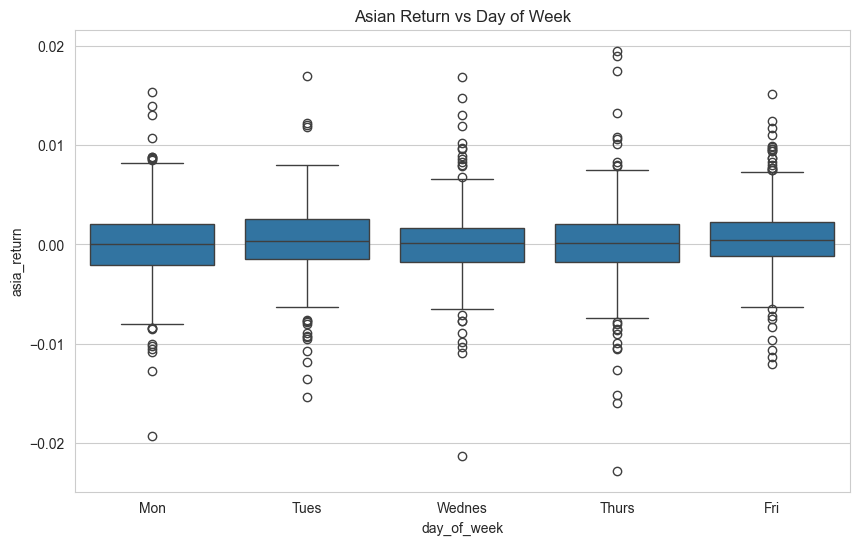

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(x='day_of_week', y='asia_return', data=df_features)
plt.title('Asian Return vs Day of Week')
plt.xticks([0,1, 2, 3, 4], ['Mon', 'Tues', 'Wednes', 'Thurs', 'Fri']) # make labels readable
plt.show()